<a href="https://www.kaggle.com/code/riteshkumarweb/agglomerative-hierarchical-clustering?scriptVersionId=323430951" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rajkumarpandey02/2023-world-population-by-country/countries-table.csv
/kaggle/input/datasets/rajkumarpandey02/2023-world-population-by-country/countries-table.json
/kaggle/input/datasets/riteshkumarweb/world-gdp-dataset/world_gdp_data.csv


In [8]:
# 📊 Agglomerative Clustering

# Agglomerative Clustering is an
# Unsupervised Machine Learning algorithm

# It belongs to:
# 🌳 Hierarchical Clustering

# 🎯 Goal:
# Group similar data points into clusters

# Unsupervised means:
# ❌ No target column (y)
# ✅ Only input features (X)


# 🧠 Idea:

# Start with:
# Each data point = One separate cluster

# Then:
# Continuously merge nearest clusters

# Until desired number of clusters is reached


# 🔁 Working

# Step 1️⃣
# Treat every data point as a cluster

# Example:
# A   B   C   D

# Step 2️⃣
# Find two closest clusters

# Example:
# A and B are closest

# Step 3️⃣
# Merge them

# (AB)   C   D

# Step 4️⃣
# Again find closest clusters

# (AB)   (CD)

# Step 5️⃣
# Continue until required
# number of clusters is obtained


# 📊 Dendrogram

# Dendrogram = Tree-like diagram

# Used to visualize
# how clusters are merged

# Also helps find best number
# of clusters


# 📦 Important Hyperparameters

# n_clusters
# → Number of final clusters

# metric
# → Distance measure

# Examples:
# 'euclidean'
# 'manhattan'
# 'cosine'

# linkage
# → Method used to merge clusters

# 'ward'
# → Minimizes variance (most common)

# 'single'
# → Minimum distance between clusters

# 'complete'
# → Maximum distance between clusters

# 'average'
# → Average distance between clusters


# 📊 Linkage Types

# Single Linkage

# Cluster A ●────●
# Cluster B      ●

# Uses nearest points


# Complete Linkage

# Uses farthest points
# between clusters


# Average Linkage

# Uses average distance
# between all points


# Ward Linkage

# Minimizes cluster variance
# Usually gives best results


# ✅ Advantages

# No need to initialize centroids
# Dendrogram provides visualization
# Works well for hierarchical data

# ❌ Disadvantages

# Slow on large datasets
# Computationally expensive
# Difficult to scale


# 📊 Simple Diagram

# Initial Clusters

# 🔵   🟢   🟡   🔴

# Merge Closest

# (🔵🟢)   🟡   🔴

# Merge Again

# (🔵🟢)   (🟡🔴)

# Final Clusters

#      Cluster 1
#      Cluster 2


# 🧠 Difference from K-Means

# K-Means:
# → Uses Centroids 📍
# → Need K before training
# → Fast

# Agglomerative:
# → Uses Hierarchical Merging 🌳
# → Dendrogram available
# → Slower but more interpretable

# Step 1: Load Data

In [9]:
df = pd.read_csv('/kaggle/input/datasets/rajkumarpandey02/2023-world-population-by-country/countries-table.csv',usecols=['area','pop2030'])

df

,area,pop2030
0,3287590.00,1514994080
1,9706961.00,1415605906
2,9372610.00,352162301
3,1904569.00,292150100
4,881912.00,274029836
...,...,...
229,102.00,4301
230,12173.00,3869
231,261.00,1948
232,12.00,2046


# Step 2: Scale Data

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#X_scaled = scaler.fit_transform(df)

# Step 3: Create Dendrogram

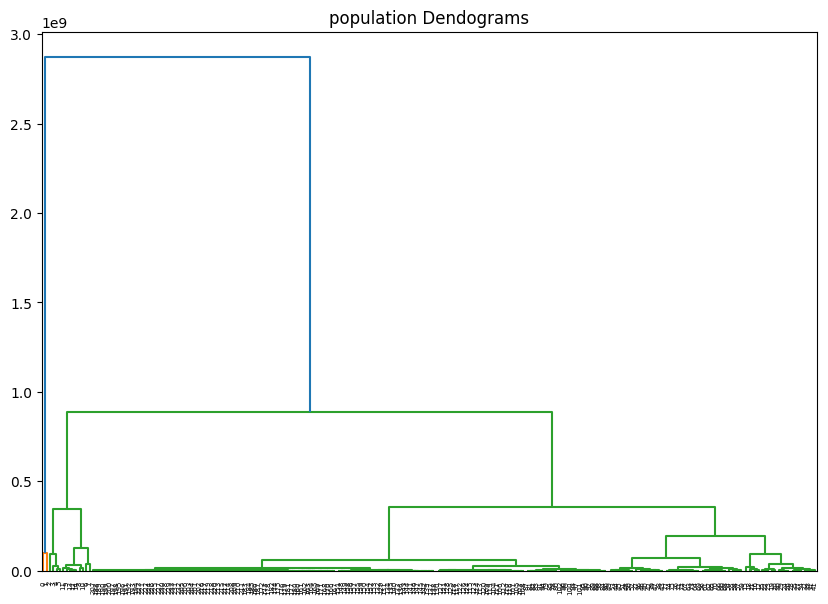

In [11]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10, 7))
plt.title("population Dendograms")
dend = shc.dendrogram(shc.linkage(df, method='ward'))

# Step 4: Train Agglomerative Clustering

In [12]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_ = cluster.fit_predict(df)

labels_

array([1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Step 5: Scatter Plot

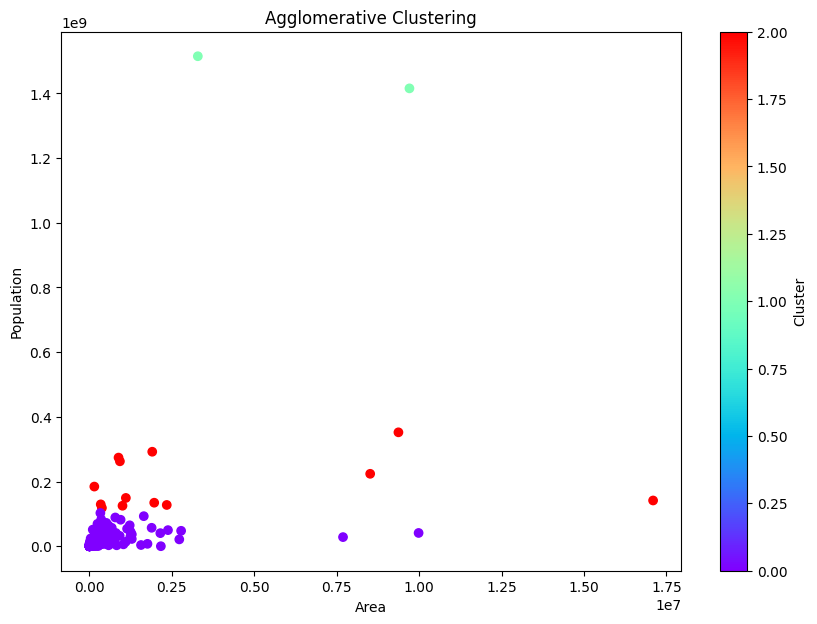

In [13]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df['area'],
    df['pop2030'],
    c=cluster.labels_,
    cmap='rainbow'
)
plt.colorbar(scatter, label='Cluster')

plt.xlabel("Area")
plt.ylabel("Population")
plt.title("Agglomerative Clustering")

plt.show()

# Step 6: See Which Rows Belong to Which Cluster

In [14]:
df['Cluster'] = labels_

df.sample(5)

,area,pop2030,Cluster
104,88361.0,6832604,0
215,160.0,41030,0
171,266000.0,662726,0
201,572.0,85798,0
183,4167.0,324860,0


# Step 1: Load Data

In [15]:
import pandas as pd

gdp = pd.read_csv(
    '/kaggle/input/datasets/riteshkumarweb/world-gdp-dataset/world_gdp_data.csv',
    encoding='latin1',
    usecols=['2023', '2024']
)

In [16]:
gdp.dropna(inplace=True)

In [17]:
gdp.shape

(191, 2)

# Step 2: Scale Data

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(gdp)

# Step 3: Create Dendrogram

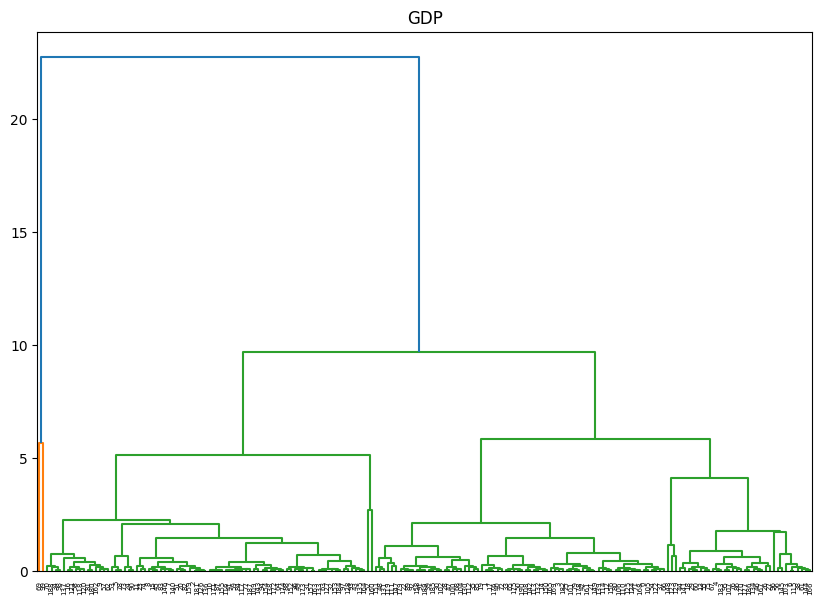

In [19]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10, 7))
plt.title("GDP")
dend = shc.dendrogram(shc.linkage(X, method='ward'))

# Step 4: Train Agglomerative Clustering

In [20]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

labels_X = cluster.fit_predict(X)

# Step 5: Scatter Plot

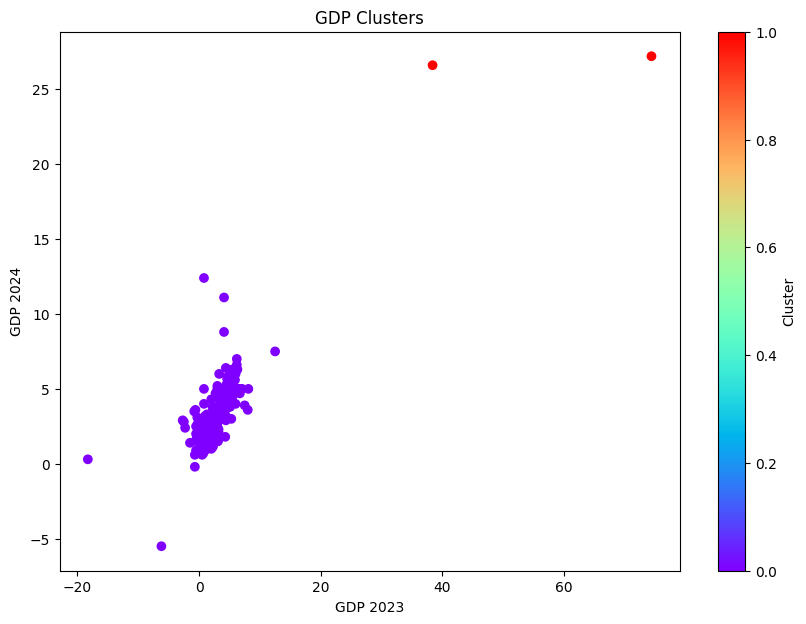

In [21]:
plt.figure(figsize=(10,7))

scatter_g = plt.scatter(
    gdp['2023'],
    gdp['2024'],
    c=labels_X,
    cmap='rainbow'
)

plt.colorbar(scatter_g, label='Cluster')

plt.xlabel("GDP 2023")
plt.ylabel("GDP 2024")
plt.title("GDP Clusters")

plt.show()

# Step 6: See Which Rows Belong to Which Cluster

In [22]:
gdp['cluster'] = labels_X

gdp.sample(5)

,2023,2024,cluster
77,6.3,6.3,0
155,1.0,2.1,0
89,2.6,2.4,0
194,3.6,4.3,0
3,2.1,1.5,0


In [23]:
print(gdp['cluster'].value_counts())

cluster
0    189
1      2
Name: count, dtype: int64
